In [1]:
import hist
from coffea.util import load, save
import mplhep as hep
import matplotlib.pyplot as plt
import copy
import numpy as np
import os
from tabulate import tabulate
import uncertainties as unc  
import uncertainties.unumpy as unumpy 
plt.style.use(hep.style.CMS)

year = "2022pre"


In [59]:
histversion = 'allcutsf'#22Test'#'GenIsoPhoTest' # 'sdfjTest'#
whathist = {
    '22preTestALL': '22preTestALL251215',
    '22Test': '22TestAllcutsxy',
    'allcuts': 'Allcuts',
    'allcutsf': 'sf',

}
lumi = {
    '2022pre' : 7.980,
    '2022post': 26.67,
    '2017': 41.48,
    '2018': 59.83
}
if 'Test' in histversion:
    hists = load('./hadmonotop'+whathist[histversion]+'.scaled')
else:
    hists = load('./hadmonotop'+year+'_'+whathist[histversion]+'.scaled')
hists['data']

{'sumw': {'MET': 0.0, 'EGamma': 0.0},
 'ut': {'MET': Hist(
    StrCategory(['sr', 'wmcr', 'tmcr', 'zmcr'], growth=True, name='region'),
    Regular(75, 250, 1000, name='ut', label='U_{T}'),
    storage=Weight()) # Sum: WeightedSum(value=36562, variance=36562) (WeightedSum(value=36703, variance=36703) with flow),
  'EGamma': Hist(
    StrCategory(['wecr', 'gcr', 'tecr', 'zecr'], growth=True, name='region'),
    Regular(75, 250, 1000, name='ut', label='U_{T}'),
    storage=Weight()) # Sum: WeightedSum(value=34806, variance=34806) (WeightedSum(value=34972, variance=34972) with flow)},
 'probT': {'MET': Hist(
    StrCategory(['sr', 'wmcr', 'tmcr', 'zmcr'], growth=True, name='region'),
    Regular(15, 0, 1, name='probT'),
    storage=Weight()) # Sum: WeightedSum(value=36703, variance=36703),
  'EGamma': Hist(
    StrCategory(['wecr', 'zecr', 'gcr', 'tecr'], growth=True, name='region'),
    Regular(15, 0, 1, name='probT'),
    storage=Weight()) # Sum: WeightedSum(value=34972, variance=34972)

In [60]:
stack = {
    'sr':[r'Z ($\nu\nu$) + Jets',r'W ($\ell\nu$) + Jets', 'WW', 'WZ', 'ZZ','TT','G + Jets','TbarWplus', 'TWminus', 'ST-s', 'ST-t', 'Z ($\ell\ell$) + Jets', 'QCD Multijet' ],
    'tw':[r'W ($\ell\nu$) + Jets', 'TT','QCD Multijet', 'WW', 'WZ', 'ZZ','TbarWplus', 'TWminus', 'ST-s', 'ST-t', 'Z ($\ell\ell$) + Jets',r'Z ($\nu\nu$) + Jets', 'G + Jets'],
    'zr':['Z ($\ell\ell$) + Jets',r'W ($\ell\nu$) + Jets', 'TT','QCD Multijet', 'WW', 'WZ', 'ZZ','TbarWplus', 'TWminus', 'ST-s', 'ST-t', r'Z ($\nu\nu$) + Jets', 'G + Jets'],
    'gr':['G + Jets',r'W ($\ell\nu$) + Jets', 'TT','QCD Multijet', 'WW', 'WZ', 'ZZ','TbarWplus', 'TWminus', 'ST-s', 'ST-t', 'Z ($\ell\ell$) + Jets',r'Z ($\nu\nu$) + Jets'],
}
stack2 = {
    'sr':[r'Z ($\nu\nu$) + Jets','TT',r'W ($\ell\nu$) 0J',r'W ($\ell\nu$) 1J',r'W ($\ell\nu$) 2J',r'W ($\ell\nu$) PTLNu', 'QCD Multijet', 'WW', 'WZ', 'ZZ','Z ($\ell\ell$) + Jets', 'G + Jets'],
    'tw':[r'W ($\ell\nu$) 0J',r'W ($\ell\nu$) 1J',r'W ($\ell\nu$) 2J',r'W ($\ell\nu$) PTLNu', 'TT','QCD Multijet', 'WW', 'WZ', 'ZZ','TbarWplus', 'TWminus', 'ST-s', 'ST-t', 'Z ($\ell\ell$) + Jets',r'Z ($\nu\nu$) + Jets', 'G + Jets'],
    'zr':['Z ($\ell\ell$) + Jets',r'W ($\ell\nu$) 0J',r'W ($\ell\nu$) 1J',r'W ($\ell\nu$) 2J',r'W ($\ell\nu$) PTLNu', 'TT','QCD Multijet', 'WW', 'WZ', 'ZZ','TbarWplus', 'TWminus', 'ST-s', 'ST-t', r'Z ($\nu\nu$) + Jets', 'G + Jets'],
    'gr':['G + Jets',r'W ($\ell\nu$) 0J',r'W ($\ell\nu$) 1J',r'W ($\ell\nu$) 2J',r'W ($\ell\nu$) PTLNu', 'TT','QCD Multijet', 'WW', 'WZ', 'ZZ','TbarWplus', 'TWminus', 'ST-s', 'ST-t', 'Z ($\ell\ell$) + Jets',r'Z ($\nu\nu$) + Jets'],
}
cat_calors = {
    'sr':["#3f90da", "#ffa90e", "#bd1f01", "#94a4a2", "#832db6", "#a96b59", "#e76300", "#b9ac70", "#717581", "#92dadd"],
}
colors = { 
    #'sr':['gold','blue','maroon','green','lightgreen','orange','brown','purple'],
    'sr':[
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
            "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
            "#bcbd22", "#17becf",
            "#aec7e8", "#ffbb78", "#98df8a", "#ff9896",
            "#c5b0d5", "#c49c94", "#f7b6d2", "#c7c7c7",
            "#dbdb8d", "#9edae5"
    ],
    'tw':[
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
            "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
            "#bcbd22", "#17becf",
            "#aec7e8", "#ffbb78", "#98df8a", "#ff9896",
            "#c5b0d5", "#c49c94", "#f7b6d2", "#c7c7c7",
            "#dbdb8d", "#9edae5"
        ],
    'zr':[
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
            "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
            "#bcbd22", "#17becf",
            "#aec7e8", "#ffbb78", "#98df8a", "#ff9896",
            "#c5b0d5", "#c49c94", "#f7b6d2", "#c7c7c7",
            "#dbdb8d", "#9edae5"
    ],
    'gr':[
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
            "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
            "#bcbd22", "#17becf",
            "#aec7e8", "#ffbb78", "#98df8a", "#ff9896",
            "#c5b0d5", "#c49c94", "#f7b6d2", "#c7c7c7",
            "#dbdb8d", "#9edae5"
    ],
}   


Start adding the stack mc & data
In zmcr sample of QCD Multijet is Not exist
In zmcr sample of ST-s is Not exist
In zmcr sample of ST-t is Not exist
In zmcr sample of Z ($\nu\nu$) + Jets is Not exist
In zmcr sample of G + Jets is Not exist
zmcr is not in QCD Multijet's hist axis
zmcr is not in ST-s's hist axis
zmcr is not in ST-t's hist axis
zmcr is not in Z ($\nu\nu$) + Jets's hist axis
zmcr is not in G + Jets's hist axis


/tmp/ipykernel_233918/2664086641.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = ds / ms
/tmp/ipykernel_233918/2664086641.py:100: RuntimeWarning: invalid value encountered in divide
  yerr=np.sqrt(datastack.view().variance) / mcstack.view().value,
/tmp/ipykernel_233918/2664086641.py:108: RuntimeWarning: invalid value encountered in divide
  (1.0 - np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],
/tmp/ipykernel_233918/2664086641.py:109: RuntimeWarning: invalid value encountered in divide
  (1.0 + np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],


Start adding the stack mc & data
In zmcr sample of QCD Multijet is Not exist
In zmcr sample of ST-s is Not exist
In zmcr sample of ST-t is Not exist
In zmcr sample of Z ($\nu\nu$) + Jets is Not exist
In zmcr sample of G + Jets is Not exist
zmcr is not in QCD Multijet's hist axis
zmcr is not in ST-s's hist axis
zmcr is not in ST-t's hist axis
zmcr is not in Z ($\nu\nu$) + Jets's hist axis
zmcr is not in G + Jets's hist axis


/tmp/ipykernel_233918/2664086641.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = ds / ms
/tmp/ipykernel_233918/2664086641.py:100: RuntimeWarning: invalid value encountered in divide
  yerr=np.sqrt(datastack.view().variance) / mcstack.view().value,
/tmp/ipykernel_233918/2664086641.py:108: RuntimeWarning: invalid value encountered in divide
  (1.0 - np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],
/tmp/ipykernel_233918/2664086641.py:109: RuntimeWarning: invalid value encountered in divide
  (1.0 + np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],


Start adding the stack mc & data
In zmcr sample of QCD Multijet is Not exist
In zmcr sample of ST-s is Not exist
In zmcr sample of ST-t is Not exist
In zmcr sample of Z ($\nu\nu$) + Jets is Not exist
In zmcr sample of G + Jets is Not exist
zmcr is not in QCD Multijet's hist axis
zmcr is not in ST-s's hist axis
zmcr is not in ST-t's hist axis
zmcr is not in Z ($\nu\nu$) + Jets's hist axis
zmcr is not in G + Jets's hist axis
Start adding the stack mc & data
In zmcr sample of QCD Multijet is Not exist
In zmcr sample of ST-s is Not exist
In zmcr sample of ST-t is Not exist
In zmcr sample of Z ($\nu\nu$) + Jets is Not exist
In zmcr sample of G + Jets is Not exist
zmcr is not in QCD Multijet's hist axis
zmcr is not in ST-s's hist axis
zmcr is not in ST-t's hist axis
zmcr is not in Z ($\nu\nu$) + Jets's hist axis
zmcr is not in G + Jets's hist axis
Start adding the stack mc & data
In zmcr sample of QCD Multijet is Not exist
In zmcr sample of ST-s is Not exist
In zmcr sample of ST-t is Not exi

...

Start adding the stack mc & data
In zmcr sample of QCD Multijet is Not exist
In zmcr sample of ST-s is Not exist
In zmcr sample of ST-t is Not exist
In zmcr sample of Z ($\nu\nu$) + Jets is Not exist
In zmcr sample of G + Jets is Not exist
zmcr is not in QCD Multijet's hist axis
zmcr is not in ST-s's hist axis
zmcr is not in ST-t's hist axis
zmcr is not in Z ($\nu\nu$) + Jets's hist axis
zmcr is not in G + Jets's hist axis


/tmp/ipykernel_233918/2664086641.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = ds / ms
/tmp/ipykernel_233918/2664086641.py:100: RuntimeWarning: invalid value encountered in divide
  yerr=np.sqrt(datastack.view().variance) / mcstack.view().value,
/tmp/ipykernel_233918/2664086641.py:108: RuntimeWarning: invalid value encountered in divide
  (1.0 - np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],
/tmp/ipykernel_233918/2664086641.py:109: RuntimeWarning: invalid value encountered in divide
  (1.0 + np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],


Start adding the stack mc & data
In zmcr sample of QCD Multijet is Not exist
In zmcr sample of ST-s is Not exist
In zmcr sample of ST-t is Not exist
In zmcr sample of Z ($\nu\nu$) + Jets is Not exist
In zmcr sample of G + Jets is Not exist
zmcr is not in QCD Multijet's hist axis
zmcr is not in ST-s's hist axis
zmcr is not in ST-t's hist axis
zmcr is not in Z ($\nu\nu$) + Jets's hist axis
zmcr is not in G + Jets's hist axis


/tmp/ipykernel_233918/2664086641.py:94: RuntimeWarning: invalid value encountered in divide
  ratio = ds / ms
/tmp/ipykernel_233918/2664086641.py:100: RuntimeWarning: invalid value encountered in divide
  yerr=np.sqrt(datastack.view().variance) / mcstack.view().value,
/tmp/ipykernel_233918/2664086641.py:108: RuntimeWarning: invalid value encountered in divide
  (1.0 - np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],
/tmp/ipykernel_233918/2664086641.py:109: RuntimeWarning: invalid value encountered in divide
  (1.0 + np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],


Start adding the stack mc & data
In zmcr sample of QCD Multijet is Not exist
In zmcr sample of ST-s is Not exist
In zmcr sample of ST-t is Not exist
In zmcr sample of Z ($\nu\nu$) + Jets is Not exist
In zmcr sample of G + Jets is Not exist
zmcr is not in QCD Multijet's hist axis
zmcr is not in ST-s's hist axis
zmcr is not in ST-t's hist axis
zmcr is not in Z ($\nu\nu$) + Jets's hist axis
zmcr is not in G + Jets's hist axis
Start adding the stack mc & data
In zmcr sample of QCD Multijet is Not exist
In zmcr sample of ST-s is Not exist
In zmcr sample of ST-t is Not exist
In zmcr sample of Z ($\nu\nu$) + Jets is Not exist
In zmcr sample of G + Jets is Not exist
zmcr is not in QCD Multijet's hist axis
zmcr is not in ST-s's hist axis
zmcr is not in ST-t's hist axis
zmcr is not in Z ($\nu\nu$) + Jets's hist axis
zmcr is not in G + Jets's hist axis
Start adding the stack mc & data
In zmcr sample of QCD Multijet is Not exist
In zmcr sample of ST-s is Not exist
In zmcr sample of ST-t is Not exi

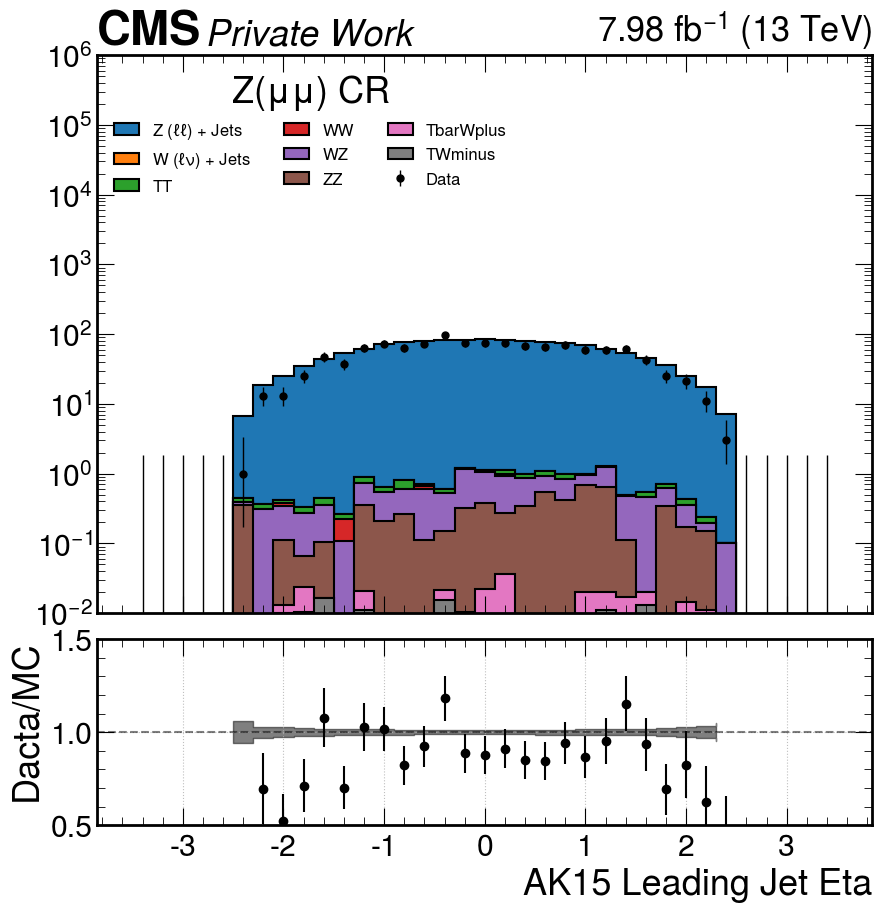

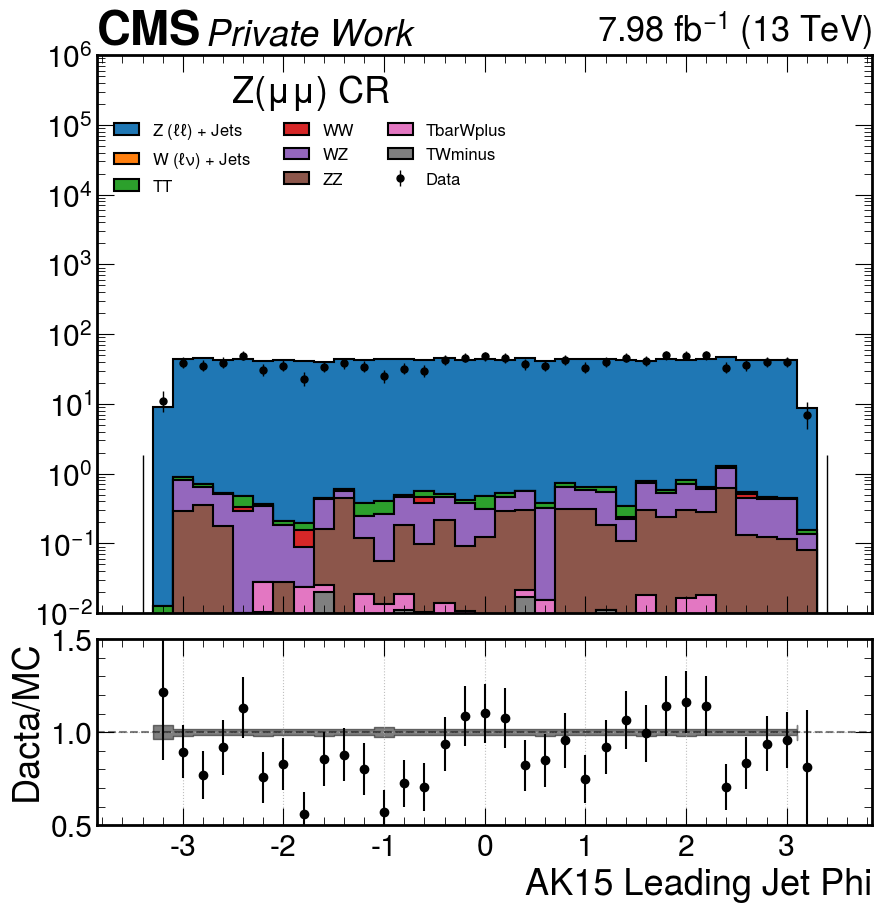

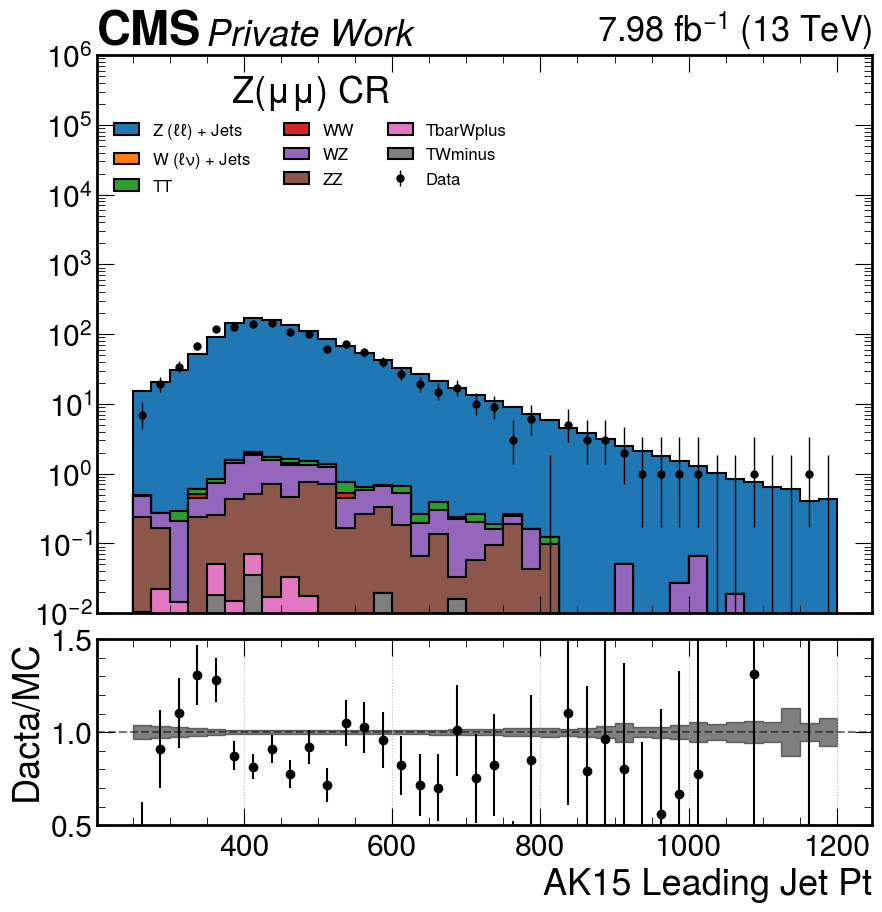

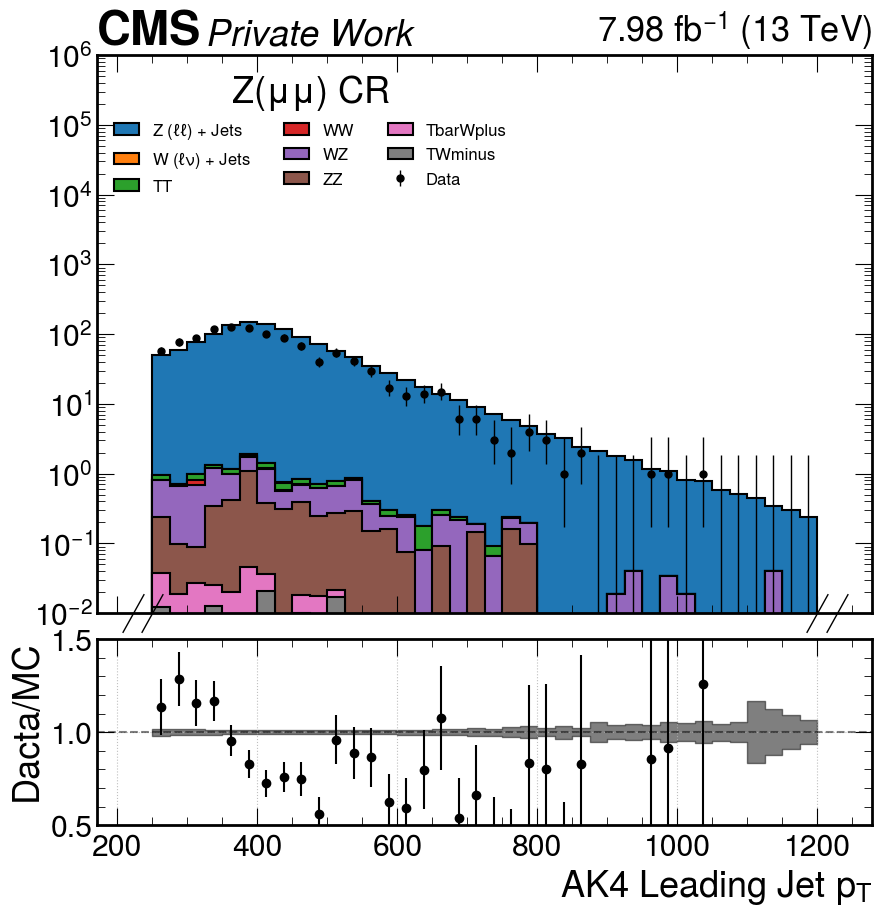

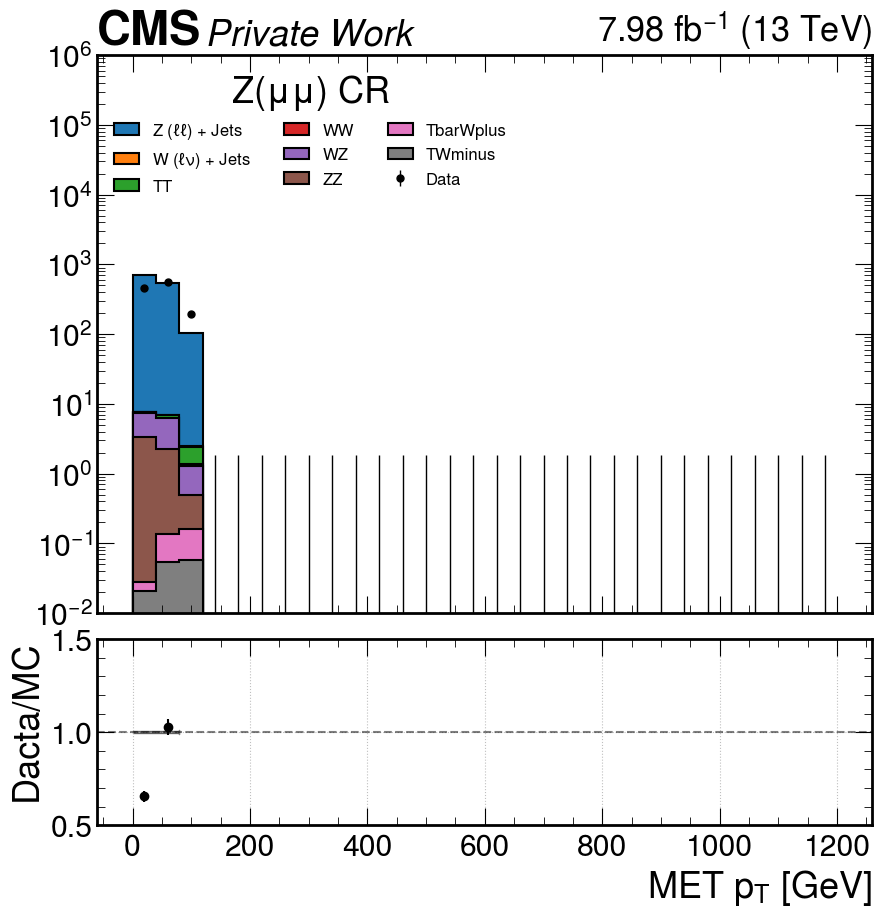

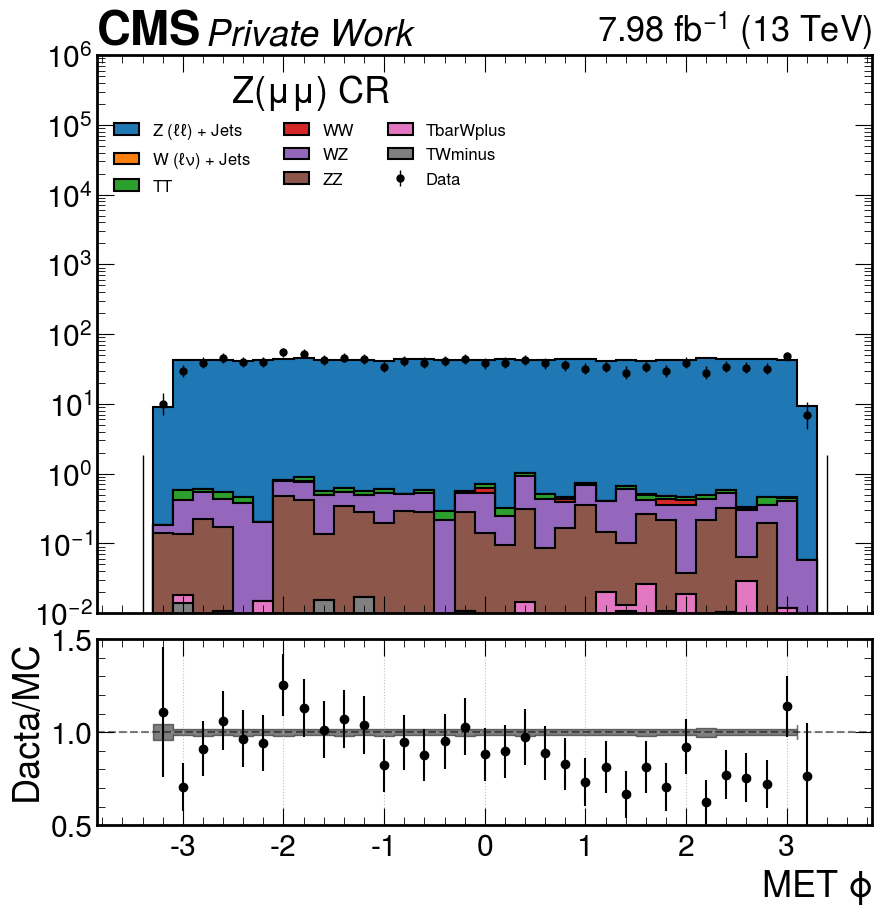

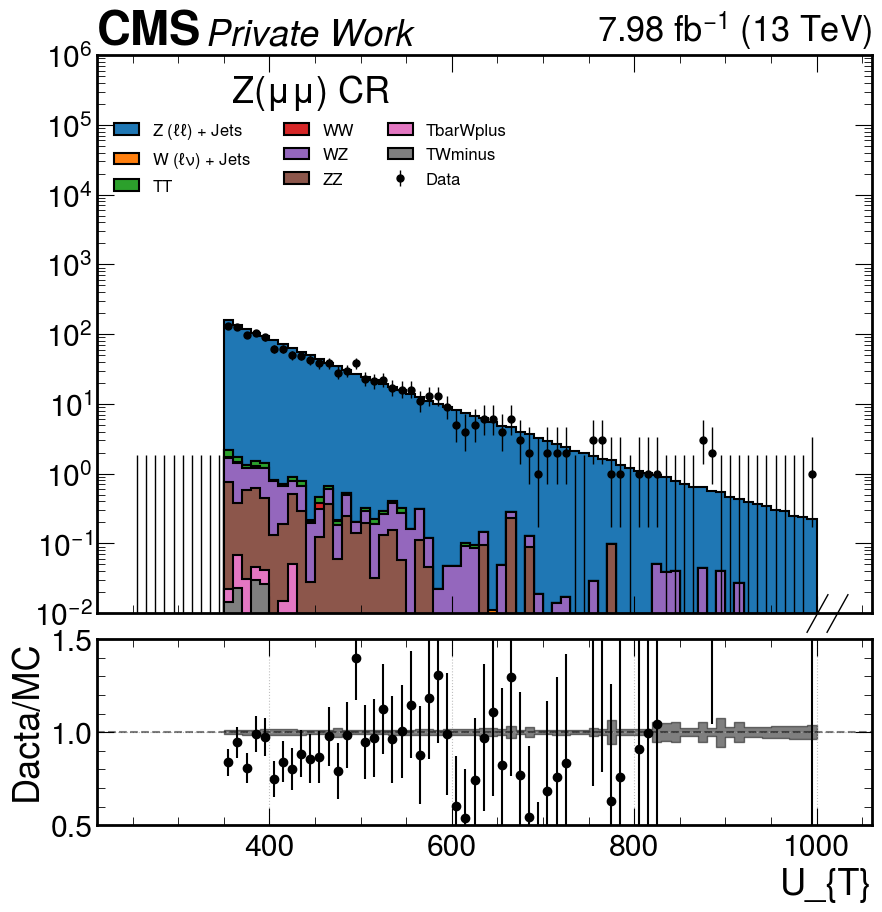

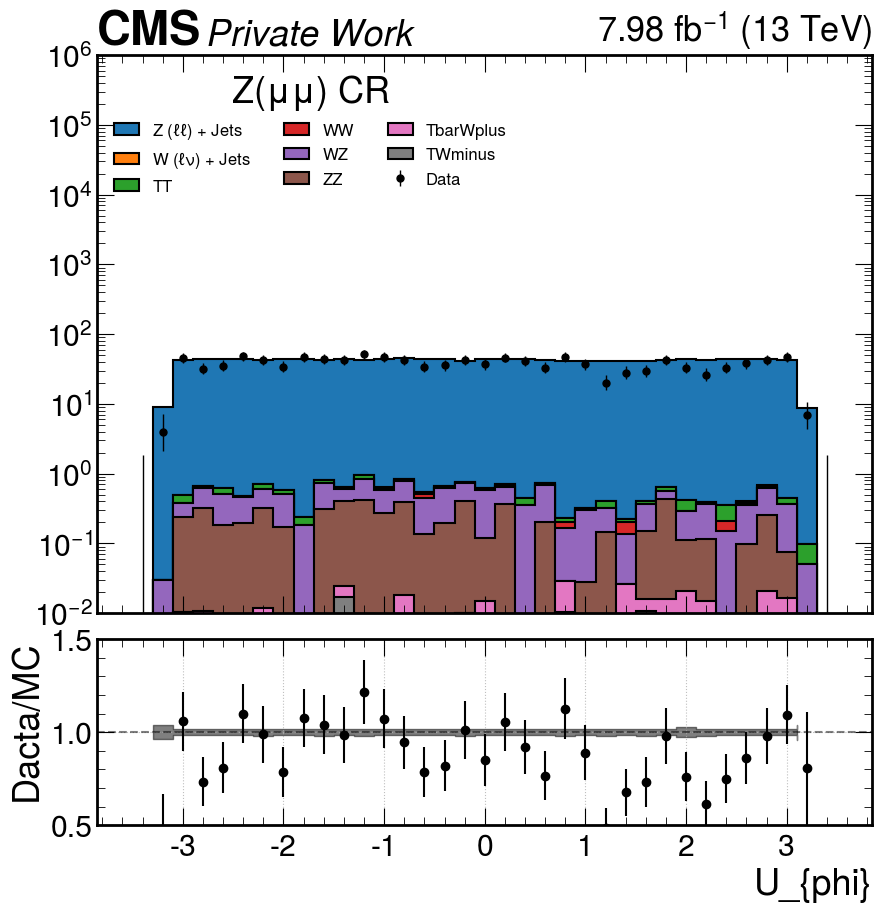

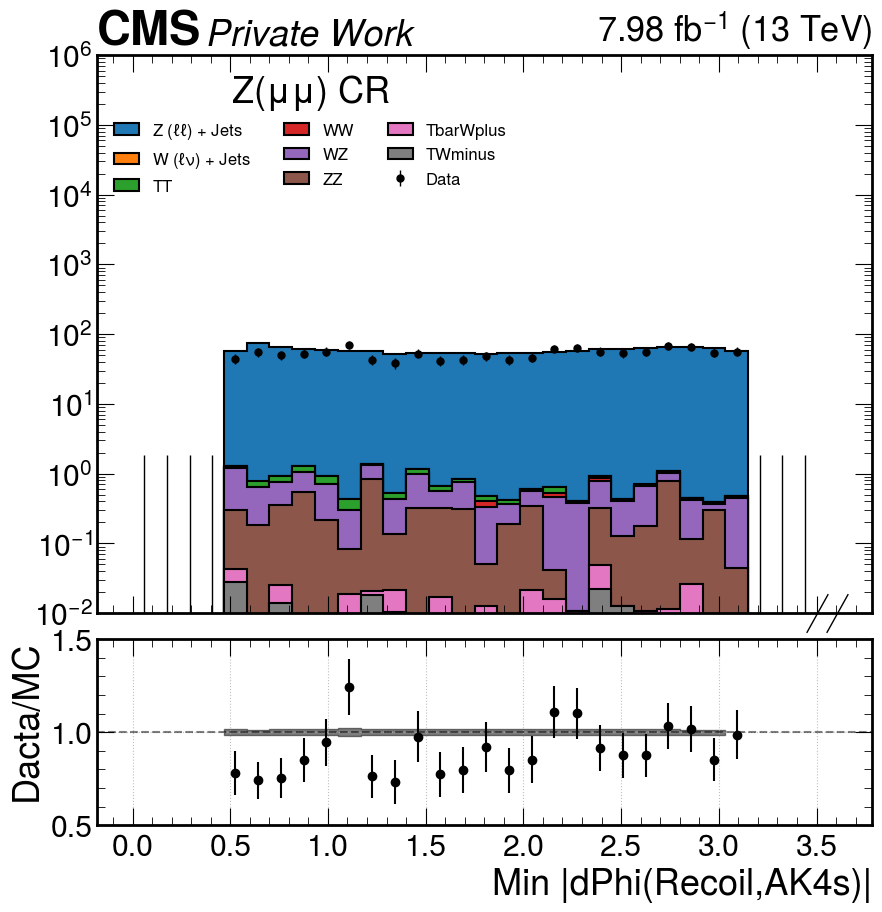

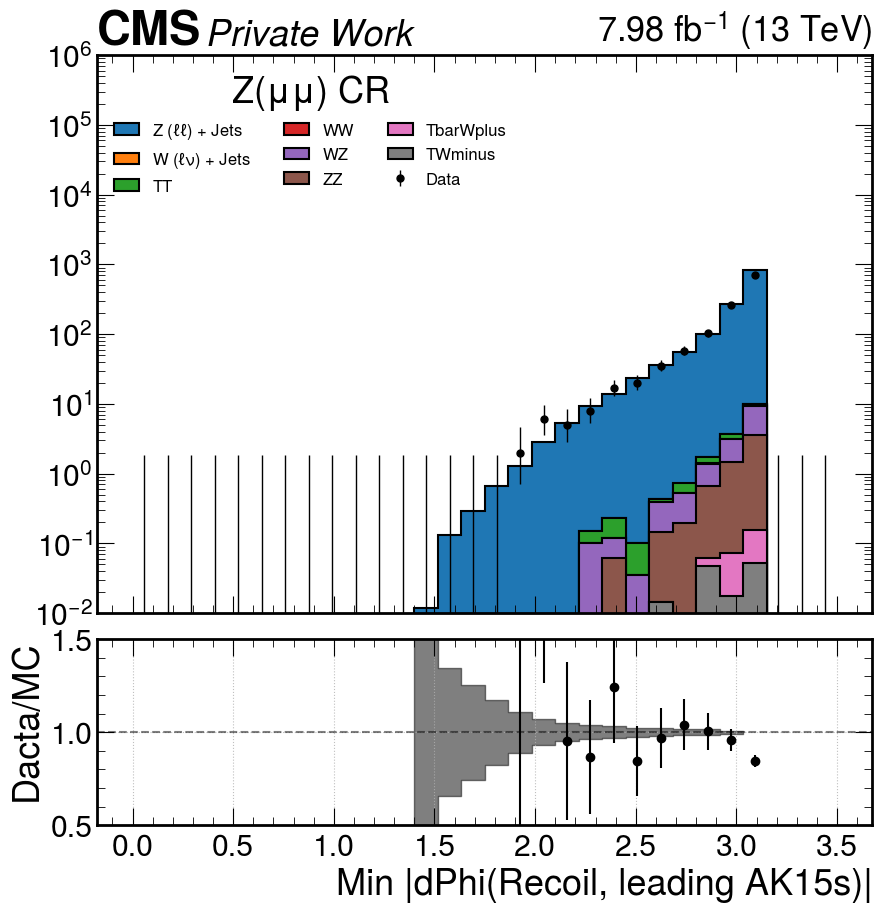

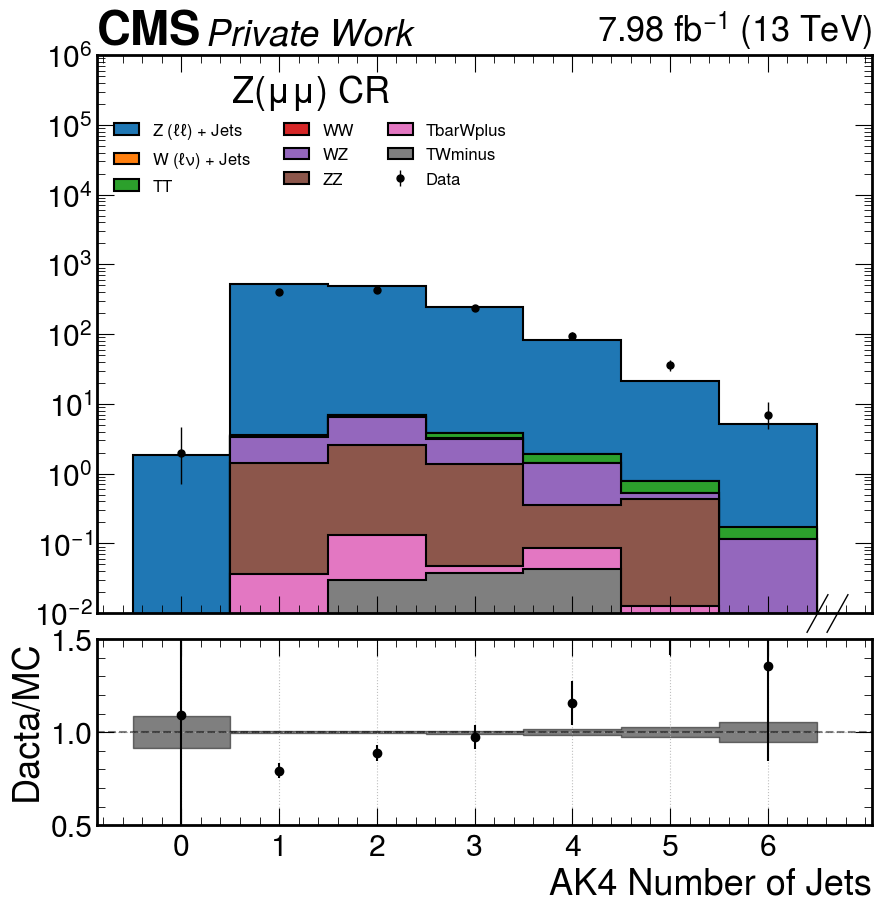

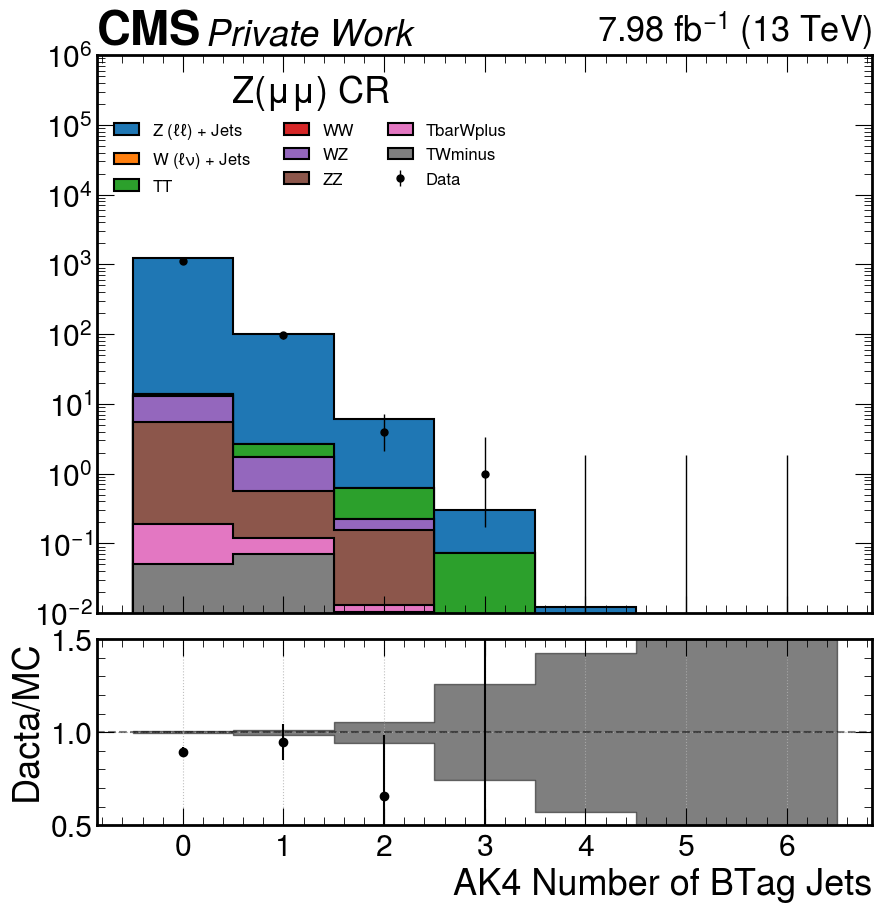

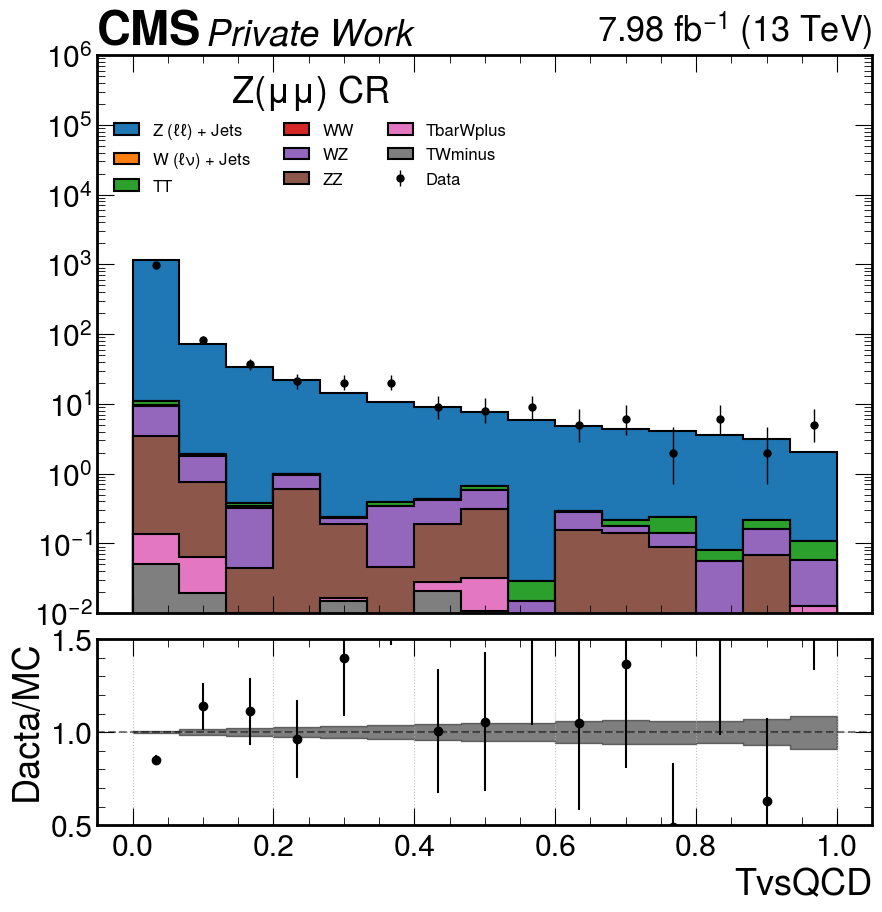

In [67]:
######
## Run key loop
######
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
from cycler import cycler
plt.style.use(hep.style.CMS)

year = '2022pre'
region = 'zmcr'
#key = 'nje'
stacks = hists['bkg']['sumw'].keys()
stack_map = 'zr'

keys = ['fjeta','fjphi','fjpt','jpt','met','metphi','ut','uphi',
        'mindphirecoil','minDphirecoil','njets','njbtagL','TvsQCD',
       ]
regions = ['sr', 'wmcr', 'wecr', 'tmcr', 'gcr', 'tecr', 'zecr', 'zmcr']
leg_reg = {
    'sr': 'SR', 'wmcr': r'W($\mu$) CR', 'wecr': r'W(e) CR', 'tmcr': r'Top($\mu$) CR', 'gcr': 'G CR',
    'tecr': r'Top(e) CR', 'zecr':r'Z(ee) CR', 'zmcr': r'Z($\mu\mu$) CR'
}

os.makedirs(f"plots{year}_{whathist[histversion]}", exist_ok=True)

for key in keys:
    fig, (ax, rax) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(10,10),
        gridspec_kw={"height_ratios": (3, 1)},
        sharex=True
    )

    fig.subplots_adjust(hspace=.07)
    hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)')
    ax.set_prop_cycle(cycler(color=colors[stack_map]))

    bkg  = hists['bkg']
    data = hists['data']
#sig = hists['sig']

    mcstack = None
    for sample in stack[stack_map]:
        #print(sample)
        try:
            target = bkg[key][sample][{'region': region}]
            bins = target.axes.edges[0]

        except:
            print(f'In {region} sample of {sample} is Not exist')
            continue

        try:
            mcstack += bkg[key][sample][{'region': region}]
            drawstack += bkg[key][sample][{'region': region}].values()
        except:
            print("Start adding the stack mc & data")
            mcstack = bkg[key][sample][{'region': region}]
            drawstack = bkg[key][sample][{'region': region}].values()

    for sample in stack[stack_map]:
        if region not in bkg[key][sample].axes["region"]:
            print(f"{region} is not in {sample}'s hist axis")
            continue
        ax.hist(bins[:-1], bins, weights=drawstack, histtype='stepfilled', label=sample, linewidth=1.5, edgecolor=(0,0,0,0.3), alpha=1.0)
        drawstack -= bkg[key][sample][{'region': region}].values()

    error_opts = {
        'step': 'post',
        'label': 'Stat. Unc.',
        'hatch': '///',
        'facecolor': 'None',
        'edgecolor': (0, 0, 0, 0.3),
        'linewidth': 0
    }

    if region == 'sr' or 'mcr' in region:
        data[key]['MET'][{'region': region}].plot1d(ax=ax, histtype='errorbar', color='k', stack=False, label='Data')
        datastack = data[key]['MET'][{'region': region}]
    else:
        data[key]['EGamma'][{'region': region}].plot1d(ax=ax, histtype='errorbar', color='k', stack=False, label='Data')
        datastack = data[key]['EGamma'][{'region': region}]

    leg = ax.legend(ncol=3, loc='upper left', fontsize=12, title= leg_reg[region])
    ax.set_yscale('log')
    ax.set_ylim(0.01, 1000000)
    ax.set_xlabel(None)
    #rax.set_xlabel(key)
    ds = datastack.view().value
    ms = mcstack.view().value

    ratio = ds / ms
    #print(ratio)

    rax.errorbar(
        x=target.axes.edges[0][:-1] + np.diff(target.axes.edges[0]) / 2,
        y=ratio,
        yerr=np.sqrt(datastack.view().variance) / mcstack.view().value,
        fmt="o",
        color="k",
    )

    rax.fill_between(
        bins,
        # append the last edge to the bins
        (1.0 - np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],
        (1.0 + np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],
        step="post",
        color="k",
        alpha=0.5,
    )

    if not key == 'template':
        lab = bkg[key][sample].axes[key].label
        rax.set_xlabel(lab)
    rax.set_ylabel('Dacta/MC')#
    rax.set_ylim(0.5, 1.5)

    rax.axhline(1, color='k', linestyle='--',alpha=0.5)
    rax.grid(True)

    fig.savefig('./plots'+year+'_'+whathist[histversion]+'/'+region+'_'+key+'_'+whathist[histversion]+'.png')

In [15]:
for reg in ['sr', 'zmcr', 'zecr', 'wmcr', 'tmcr', 'tecr', 'wecr', 'gcr']:
    if reg not in bkg[key]['ZZ'].axes["region"]:
        print(f"{reg} is not in hist axis")
bkg[key]['ZZ'].axes["region"]#[{'region': region}]

tecr is not in hist axis


StrCategory(['sr', 'zmcr', 'zecr', 'wmcr', 'tmcr', 'wecr', 'gcr'], growth=True, name='region')

W ($\ell\nu$) + Jets
In wmcr sample of W ($\ell\nu$) + Jets is Not exist
TT
In wmcr sample of TT is Not exist
QCD Multijet
In wmcr sample of QCD Multijet is Not exist
WW
In wmcr sample of WW is Not exist
WZ
In wmcr sample of WZ is Not exist
ZZ
In wmcr sample of ZZ is Not exist
TbarWplus
In wmcr sample of TbarWplus is Not exist
TWminus
In wmcr sample of TWminus is Not exist
ST-s
In wmcr sample of ST-s is Not exist
ST-t
In wmcr sample of ST-t is Not exist
Z ($\ell\ell$) + Jets
In wmcr sample of Z ($\ell\ell$) + Jets is Not exist
Z ($\nu\nu$) + Jets
In wmcr sample of Z ($\nu\nu$) + Jets is Not exist
G + Jets
In wmcr sample of G + Jets is Not exist
wmcr is not in W ($\ell\nu$) + Jets's hist axis
wmcr is not in TT's hist axis
wmcr is not in QCD Multijet's hist axis
wmcr is not in WW's hist axis
wmcr is not in WZ's hist axis
wmcr is not in ZZ's hist axis
wmcr is not in TbarWplus's hist axis
wmcr is not in TWminus's hist axis
wmcr is not in ST-s's hist axis
wmcr is not in ST-t's hist axis
wmc

KeyError: "'wmcr' not in axis"

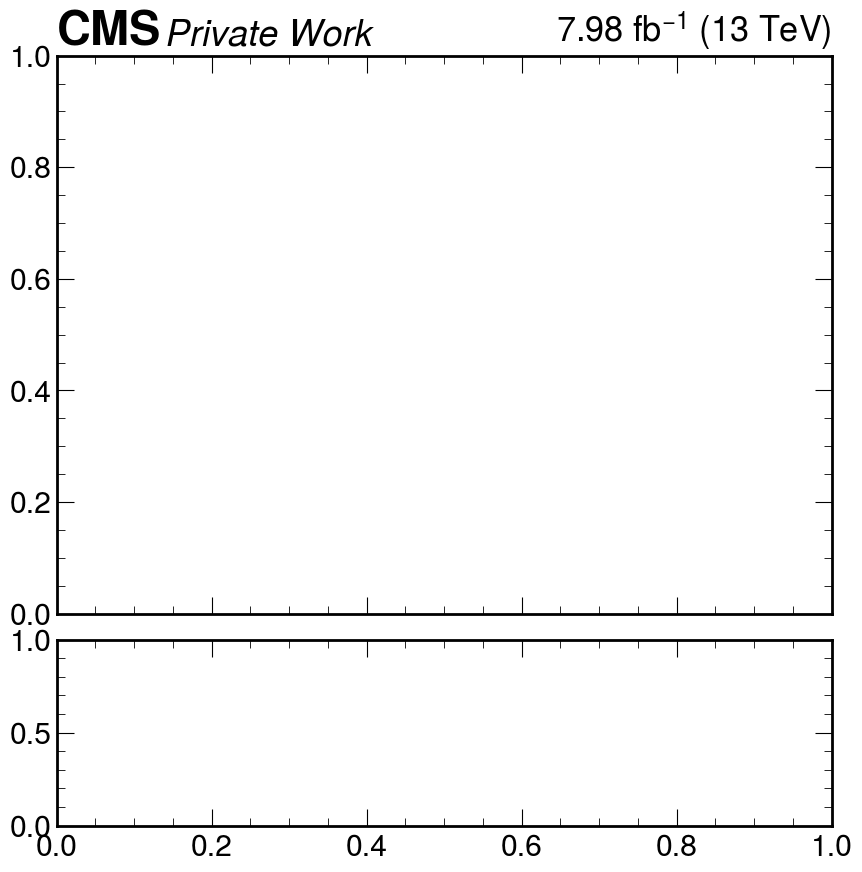

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import mplhep as hep
from cycler import cycler
plt.style.use(hep.style.CMS)

year = '2022pre'
region = 'wmcr'
key = 'dimupt'
stacks = hists['bkg']['sumw'].keys()
stack_map = 'tw'

regions = ['sr', 'wmcr', 'wecr', 'tmcr', 'gcr', 'tecr', 'zecr', 'zmcr']
leg_reg = {
    'sr': 'SR', 'wmcr': r'W($\mu$) CR', 'wecr': r'W(e) CR', 'tmcr': r'Top($\mu$) CR', 'gcr': 'G CR',
    'tecr': r'Top(e) CR', 'zecr':r'Z(ee) CR', 'zmcr': r'Z($\mu\mu$) CR'
}

fig, (ax, rax) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10,10),
    gridspec_kw={"height_ratios": (3, 1)},
    sharex=True
)

fig.subplots_adjust(hspace=.07)
hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)')
ax.set_prop_cycle(cycler(color=colors[stack_map]))

bkg  = hists['bkg']
data = hists['data']
#sig = hists['sig']

mcstack = None
for sample in stack[stack_map]:
    print(sample)
    #if 'G' in sample: continue
    #if 'nu' in sample: continue
    #if 'W' in sample: continue
    #if 'Z' in sample: continue
    #if 'QCD' in sample: continue
    try:
        target = bkg[key][sample][{'region': region}]
        bins = target.axes.edges[0]

    except:
        print(f'In {region} sample of {sample} is Not exist')
        continue

    try:
        mcstack += bkg[key][sample][{'region': region}]
        drawstack += bkg[key][sample][{'region': region}].values()
    except:
        print("Start adding the stack mc & data")
        mcstack = bkg[key][sample][{'region': region}]
        drawstack = bkg[key][sample][{'region': region}].values()

for sample in stack[stack_map]:
    #if 'G' in sample: continue
    #if 'nu' in sample: continue
    #if 'W' in sample: continue
    #if 'Z' in sample: continue
    #if 'QCD' in sample: continue
    if region not in bkg[key][sample].axes["region"]:
        print(f"{region} is not in {sample}'s hist axis")
        continue
    ax.hist(bins[:-1], bins, weights=drawstack, histtype='stepfilled', label=sample, linewidth=1.5, edgecolor=(0,0,0,0.3), alpha=1.0)
    drawstack -= bkg[key][sample][{'region': region}].values()
    
    #target.plot1d(ax=ax, overlay="dataset", stack=True, histtype='fill',edgecolor=(0,0,0,0.3), alpha=1.0, linewidth=1.5,label=sample)
    #if key == 'met':
    #    rax.set_xlabel(r'E$_{T}$ (GeV)')
error_opts = {
    'step': 'post',
    'label': 'Stat. Unc.',
    'hatch': '///',
    'facecolor': 'None',
    'edgecolor': (0, 0, 0, 0.3),
    'linewidth': 0
}
#unc_low =  mcstack.view().value - np.sqrt(mcstack.view().variance)
#unc_high = mcstack.view().value + np.sqrt(mcstack.view().variance)
#ax.fill_between(bins[:-1], unc_low, unc_high, **error_opts)

if region == 'sr' or 'mcr' in region:
    data[key]['MET'][{'region': region}].plot1d(ax=ax, histtype='errorbar', color='k', stack=False, label='Data')
    datastack = data[key]['MET'][{'region': region}]
else:
    data[key]['EGamma'][{'region': region}].plot1d(ax=ax, histtype='errorbar', color='k', stack=False, label='Data')
    datastack = data[key]['EGamma'][{'region': region}]

leg = ax.legend(ncol=3, loc='upper left', fontsize=12, title= leg_reg[region])
ax.set_yscale('log')
ax.set_ylim(0.01, 1000000)
ax.set_xlabel(None)
#rax.set_xlabel(key)
ds = datastack.view().value
ms = mcstack.view().value
#print(ds)
#print(ms)
ratio = ds / ms
#print(ratio)

rax.errorbar(
    x=target.axes.edges[0][:-1] + np.diff(target.axes.edges[0]) / 2,
    y=ratio,
    yerr=np.sqrt(datastack.view().variance) / mcstack.view().value,
    fmt="o",
    color="k",
)

rax.fill_between(
    bins,
    # append the last edge to the bins
    (1.0 - np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],
    (1.0 + np.sqrt(mcstack.view().variance) / mcstack.view().value).tolist() + [1.0],
    step="post",
    color="k",
    alpha=0.5,
)

if not key == 'template':
    lab = bkg[key][sample].axes[key].label
    rax.set_xlabel(lab)
rax.set_ylabel('Dacta/MC')#
rax.set_ylim(0.5, 1.5)
#rax.set_xlim(target.axes.edges[0][0], target.axes.edges[0][-1])
#rax.set_xlim(ratio.min(), ratio.max())
rax.axhline(1, color='k', linestyle='--',alpha=0.5)
rax.grid(True)

fig.savefig('./plots_'+whathist[histversion]+'/'+region+'_'+key+'_'+whathist[histversion]+'.png')

In [119]:
data_hists = hists['data']
fj_pt = data_hists['elept']
print(fj_pt['EGamma'].values())
print(fj_pt['EGamma'])

[[518. 387. 250. 187. 136. 126.  90.  66.  51.  46.  29.  27.  16.  10.
    9.   7.   8.   5.   4.   4.   5.   4.   1.   2.   2.   1.   3.   1.
    0.   2.   0.   0.   0.   0.   0.   1.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
    0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]]
Hist(
  StrCategory(['wecr', 'gcr'], growth=True, name='region'),
  Regular(38, 250, 1200, name='elept', label='Leading Electron Pt'),
  storage=Weight()) # Sum: WeightedSum(value=1998, variance=1998) (WeightedSum(value=48304, variance=48304) with flow)


In [120]:
bkg_hists = hists['bkg']
fj_pt_bkg = bkg_hists['elept']
fj_pt_bkg['Z ($\\ell\\ell$) + Jets'].sum()
print(fj_pt_bkg.keys())

dict_keys(['WW', 'WZ', 'ZZ', 'QCD Multijet', 'TT', 'TbarWplus', 'TWminus', 'ST-s', 'ST-t', 'Z ($\\nu\\nu$) + Jets', 'Z ($\\ell\\ell$) + Jets', 'W ($\\ell\\nu$) + Jets', 'G + Jets'])


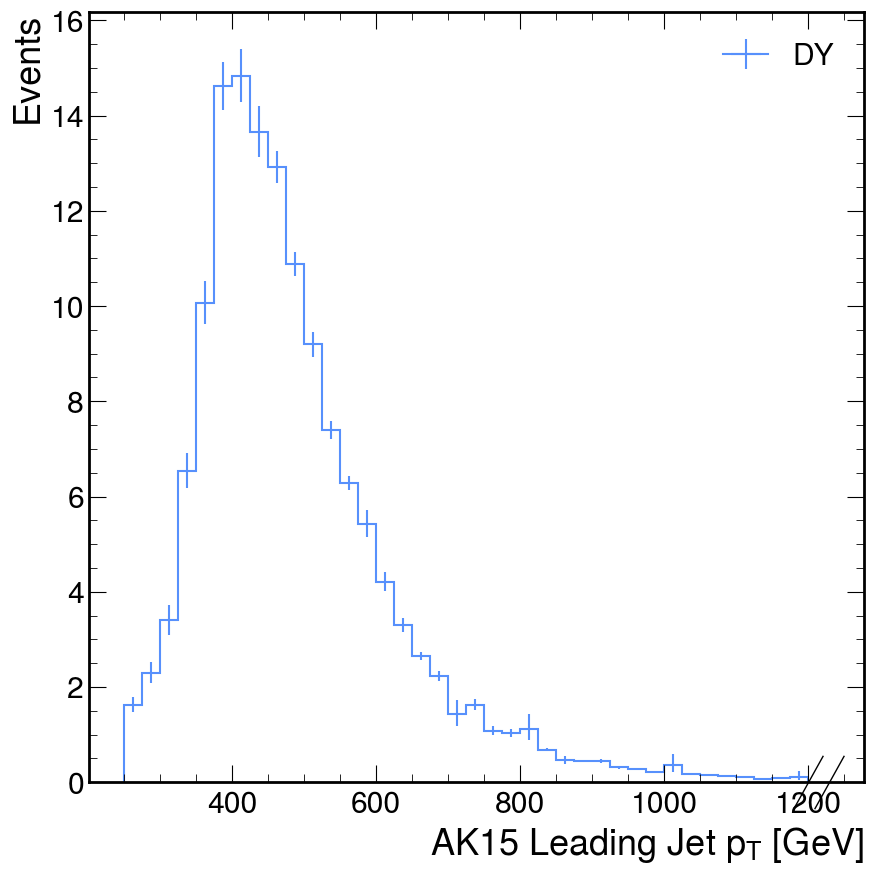

In [121]:
data_hists = hists['bkg']
fj_pt = data_hists['fjpt']
import matplotlib.pyplot as plt
import mplhep as hep

region = 'wecr'

hep.style.use("CMS")

fig, ax = plt.subplots()

hep.histplot(
    fj_pt['Z ($\\ell\\ell$) + Jets'][{'region': region}],
    ax=ax,
    label="DY",
)

ax.set_xlabel("AK15 Leading Jet $p_T$ [GeV]")
ax.set_ylabel("Events")
ax.legend()

plt.show()


Hist(
  StrCategory(['wecr', 'gcr'], growth=True, name='region'),
  Regular(38, 250, 1200, name='fjpt', label='AK15 Leading Jet Pt'),
  storage=Weight()) # Sum: WeightedSum(value=48130, variance=48130) (WeightedSum(value=48304, variance=48304) with flow)
WeightedSum(value=12970, variance=12970)


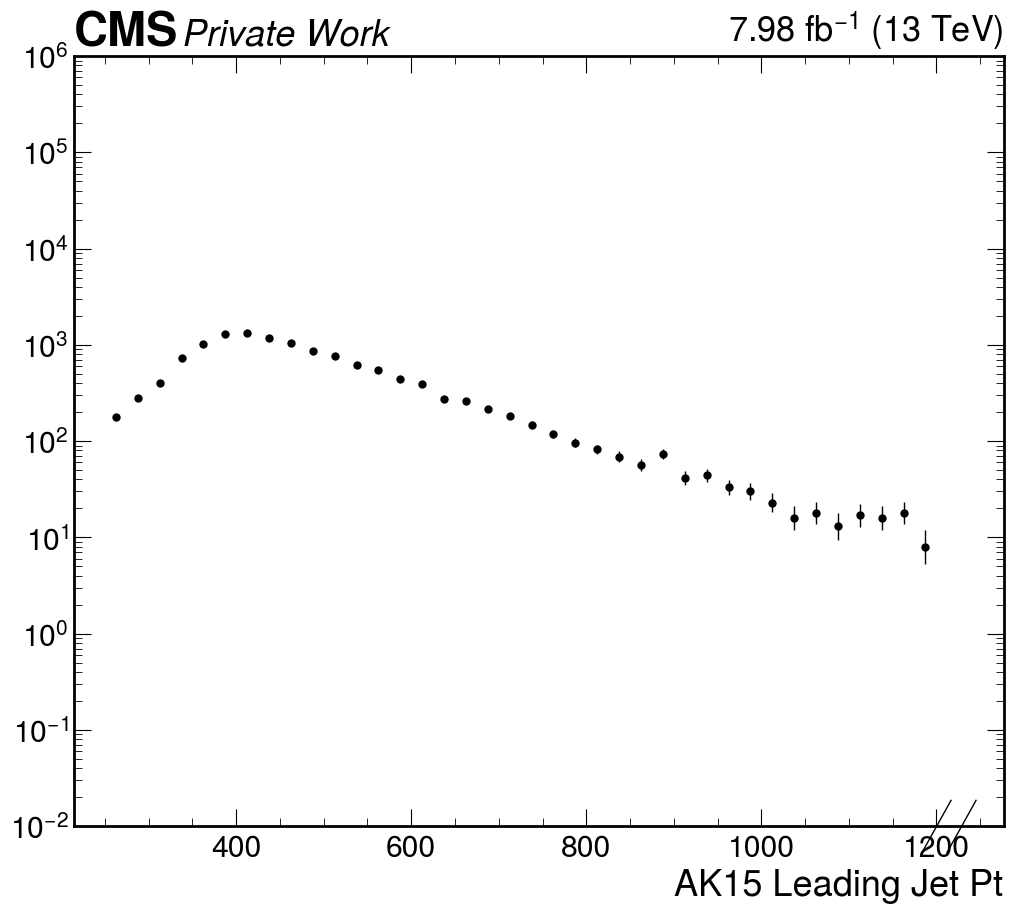

In [122]:
####
## myntuple draw
####
region = 'wecr'
vari = 'fjpt'
data_hists = hists['data']
nevent = data_hists[vari]['EGamma']
print(nevent)
describe = ''
plt.style.use(hep.style.CMS)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(12,10),
)
hep.cms.label(ax=ax, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)')
recoil_dist = data_hists[vari]['EGamma'][{ 'region': region}]
print(recoil_dist.sum())
recoil_dist.plot1d(ax=ax, histtype='errorbar', color='k', stack=False, label='DY selected')
#ax.set_xlim(0,2000)
ax.set_ylim(0.01,1000000)
ax.set_yscale('log')

#plt.savefig('./egmNTuple_recoil.png')

In [136]:
print(bkg[key]['ZZ'])

Hist(
  StrCategory(['sr', 'wmcr', 'tmcr', 'wecr', 'gcr'], growth=True, name='region'),
  Regular(38, 250, 1200, name='jpt', label='AK4 Leading Jet $p_{T}$'),
  storage=Weight()) # Sum: WeightedSum(value=64.2, variance=6.65035) (WeightedSum(value=75.999, variance=7.84889) with flow)
